### 1. 초기 설정

In [ ]:
# 라이브러리 import
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import konlpy
import numpy as np
import re
import time
import tensorflow as tf

# 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 버전 확인
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Matplotlib:", matplotlib.__version__)
print("TensorFlow:", tf.__version__)

Pandas: 2.2.3
PyTorch: 2.10.0+cpu
Matplotlib: 3.10.0
TensorFlow: 2.20.0


### 2. 데이터 로드 및 전처리

In [ ]:
from konlpy.tag import Mecab, Okt

# 데이터 로드
def load_data(ko_path, en_path):
    with open(ko_path, 'r', encoding='utf-8') as f:
        ko_data = f.read().splitlines()
    with open(en_path, 'r', encoding='utf-8') as f:
        en_data = f.read().splitlines()
    combined = set(zip(ko_data, en_data))
    return list(combined)

cleaned_corpus = load_data('korean-english-park.train.ko', 'korean-english-park.train.en')

# 토크나이저 설정
try:
    tokenizer = Mecab()
    def tokenize_ko(sentence):
        return tokenizer.morphs(sentence)
    print("Mecab is being used.")
except Exception as e:
    print(f"Mecab failed: {e}. Falling back to Okt.")
    tokenizer = Okt()
    def tokenize_ko(sentence):
        return tokenizer.morphs(sentence)

# 전처리
def preprocessing(sentence, is_korean=True):
    sentence = str(sentence).lower().strip()
    if is_korean:
        sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", sentence)
        return tokenize_ko(sentence)
    else:
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r'[" "]+', " ", sentence)
        sentence = sentence.strip()
        sentence = '<start> ' + sentence + ' <end>'
        return sentence.split()

kor_corpus = []
eng_corpus = []

# 데이터 필터링
for ko, en in cleaned_corpus:
    ko_tokens = preprocessing(ko, is_korean=True)
    en_tokens = preprocessing(en, is_korean=False)
    if len(ko_tokens) <= 40 and len(en_tokens) <= 40:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

print(f"Final filtered kor_corpus size: {len(kor_corpus)}")

Mecab failed: Install MeCab in order to use it: http://konlpy.org/en/latest/install/. Falling back to Okt.
Final filtered kor_corpus size: 68284


**데이터 로드 및 중복 제거**
- load_data 함수: 한국어와 영어 파일을 각각 읽어온 뒤, zip으로 묶어 한 쌍(Pair)으로 만듦
- 중복 제거: set() 자료구조를 사용하여 코퍼스 내에 존재하는 중복된 문장 쌍을 제거

**토큰화**
- Mecab vs Okt: 속도가 빠른 Mecab 사용을 우선 시도하고, 설치 환경에 따라 실행이 어려울 경우 Okt를 대안으로 사용

**데이터 정제 및 정규화 (Preprocessing)**
- 공통 처리: 모든 문장을 소문자로 변환하고 양 끝의 공백을 제거
- 한국어 특화: 한글과 공백을 제외한 모든 특수문자나 숫자를 제거
- 영어 특화: 구두점(?, !, .) 앞뒤에 공백을 추가하여 단어와 구두점을 분리. + <start>와 <end>를 붙여줌.

**코퍼스 필터링 및 최종 준비**
- 길이 제한: 40개 이하인 문장들만 선별하여 kor_corpus와 eng_corpus에 담음.
- 결과 확인: 최종적으로 필터링을 거쳐 살아남은 데이터의 개수를 출력하여 학습 규모를 확인함.

### 3. 벡터화

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 사용할 최대 단어 사전 크기 정의
VOCAB_SIZE = 10000

# 텍스트를 정수 시퀀스로 변환
def tokenize(corpus):
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='', oov_token='<unk>')
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequences(tensor, padding='post') # 패딩
    return tensor, tokenizer

kor_tensor, kor_tokenizer = tokenize(kor_corpus)
eng_tensor, eng_tokenizer = tokenize(eng_corpus)

# 변환된 텐서의 Shape 출력
print("Korean Tensor Shape:", kor_tensor.shape)
print("English Tensor Shape:", eng_tensor.shape)

Korean Tensor Shape: (68284, 40)
English Tensor Shape: (68284, 40)


**단어 사전 구축 및 정수 인코딩**
- VOCAB_SIZE = 10000: 전체 단어 중 빈도수가 높은 상위 10,000개 단어만 사용하도록 제한
- filters='': 이미 앞 단계에서 정규표현식으로 특수문자를 제거했으므로, 추가적인 필터링을 하지 않도록 설정
- oov_token='<unk>': 사전에 없는 단어(OOV)가 등장할 경우 모두 <unk>로 치환하여 에러를 방지
- fit_on_texts & texts_to_sequences: 텍스트 데이터를 분석하여 '단어:숫자' 대응 표를 만들고, 모든 문장을 그 숫자의 리스트로 변환

**문장 길이 통일 (Padding)**
- padding='post': 문장의 길이가 짧은 데이터의 뒤쪽에 숫자 0을 채워 넣음

**텐서 형태 확인**
- kor_tensor.shape & eng_tensor.shape: 변환된 결과물의 크기를 확인
- 68,284개의 문장이 각각 40개의 숫자로 변환되어 모델에 들어갈 준비가 끝났음을 의미

### 모델 설계

In [4]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        hidden_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(
            self.W1(values) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.enc_units,
                                      return_sequences=True,
                                      return_state=True,
                                      recurrent_initializer='glorot_uniform')

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru(x, initial_state=hidden)
        return output, state

    def initialize_hidden_state(self):
        return tf.zeros((self.batch_sz, self.enc_units))

class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.dec_units,
                                      return_sequences=True,
                                      return_state=True,
                                      recurrent_initializer='glorot_uniform')
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state, attention_weights

BATCH_SIZE = 64
EMBEDDING_DIM = 256
UNITS = 256
encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, UNITS, BATCH_SIZE)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, UNITS, BATCH_SIZE)

**Bahdanau Attention**
- 동작 원리: 현재 디코더의 상태(query)와 인코더의 모든 출력값(values)을 비교하여 유사도를 계산
- Softmax: 계산된 유사도를 확률값(0~1 사이)으로 변환한다. 이 값이 높을수록 모델이 해당 단어를 중요하게 보고 있다는 뜻임.
- Context Vector: 어텐션 가중치와 인코더 출력값을 곱해 '현재 시점에서 가장 중요한 정보'만 담은 벡터를 만듦.

**Encoder**
- Embedding: 숫자로 된 단어 인덱스를 고차원의 밀집 벡터 공간으로 투영
- GRU : 문장의 순차적인 정보를 학습합니다. return_sequences=True 설정을 통해 모든 시점의 정보를 디코더에 전달할 수 있도록 준비

**Decoder**
- 인코더가 전달한 정보와 어텐션을 활용해 한 단어씩 영어 문장을 생성.
- Attention 연동: 매 단계마다 어텐션을 호출하여 인코더 정보 중 필요한 부분을 가져온다.
- Concatenation: context_vector와 현재 입력 단어의 임베딩을 합쳐서 GRU에 입력.

**Fully Connected(Dense)**
- 최종적으로 다음에 올 단어가 10,000개의 단어 중 무엇인지 예측합니다.

**Hyperparameters**
- BATCH_SIZE = 64: 한 번에 64개의 문장 쌍을 동시에 학습한다.
- EMBEDDING_DIM & UNITS = 256: 단어를 표현하는 벡터의 크기와 GRU 내부 신경망의 크기를 256으로 설정하여 충분한 학습 표현력을 확보

### 학습 및 평가

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0
    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([eng_tokenizer.word_index['<start>']] * BATCH_SIZE, 1)

        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = (loss / int(targ.shape[1]))
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    return batch_loss

def evaluate(sentence):
    attention_plot = np.zeros((40, 40))
    sentence = preprocessing(sentence)
    
    def get_token_id(word):
        idx = kor_tokenizer.word_index.get(word, kor_tokenizer.word_index['<unk>'])
        if idx >= VOCAB_SIZE:
            return kor_tokenizer.word_index['<unk>']
        return idx

    inputs = [get_token_id(i) for i in sentence]
    inputs = pad_sequences([inputs], maxlen=40, padding='post')
    inputs = tf.convert_to_tensor(inputs)
    
    result = ''
    hidden = [tf.zeros((1, UNITS))]
    enc_out, enc_hidden = encoder(inputs, hidden)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([eng_tokenizer.word_index['<start>']], 0)

    for t in range(40):
        predictions, dec_hidden, attention_weights = decoder(dec_input, dec_hidden, enc_out)
        attention_weights = tf.reshape(attention_weights, (-1, ))
        attention_plot[t] = attention_weights.numpy()
        predicted_id = tf.argmax(predictions[0]).numpy()
        result += eng_tokenizer.index_word.get(predicted_id, '<unk>') + ' '
        if eng_tokenizer.index_word.get(predicted_id) == '<end>':
            return result, sentence, attention_plot
        dec_input = tf.expand_dims([predicted_id], 0)
    return result, sentence, attention_plot

def translate(sentence):
    result, sentence, attention_plot = evaluate(sentence)
    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

def visualize_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')
    fontdict = {'fontsize': 14}
    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.show()

BUFFER_SIZE = len(kor_tensor)
steps_per_epoch = len(kor_tensor)//BATCH_SIZE
dataset = tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

EPOCHS = 10
test_sentences = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]

for epoch in range(EPOCHS):
    start = time.time()
    enc_hidden = encoder.initialize_hidden_state()
    total_loss = 0
    for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
        batch_loss = train_step(inp, targ, enc_hidden)
        total_loss += batch_loss
        if batch % 100 == 0: print('Epoch {} Batch {} Loss {:.4f}'.format(epoch + 1, batch, batch_loss.numpy()))
    print('Epoch {} Loss {:.4f}'.format(epoch + 1, total_loss / steps_per_epoch))
    for s in test_sentences: translate(s)

**Optimizer & Loss**
- Adam: 모델의 가중치를 효율적으로 업데이트하는 최적화 도구
- Masking: 데이터 전처리 때 문장 길이를 맞추기 위해 채워 넣은 '0(Padding)' 부분은 학습에 반영되지 않도록 가려주는(mask) 역할

**학습 단계**
- GradientTape: 모델이 예측한 값과 정답 사이의 오차를 계산하고, 그 오차를 줄이기 위해 각 신경망이 얼마나 변해야 하는지(기울기)를 기록
- 학습 중 디코더의 다음 입력으로 모델의 예측값이 아닌 '실제 정답'을 넣어주어 학습 속도를 높이는 기법을 사용

**Evaluate & Translate**
- evaluate: 입력 문장을 토큰화하고 인코더-디코더를 통과시켜 번역문을 생성
- get_token_id: 앞서 발생했던 인덱스 에러를 방지하기 위해, 단어 사전 범위를 벗어나는 단어는 자동으로 <unk>로 처리하는 안전 장치가 포함

**어텐션 맵**
- 모델이 번역을 할 때 어떤 단어에 집중했는지 보여줌

**전체 학습 루프**
- tf.data.Dataset: 6만 개 이상의 데이터를 효율적으로 관리하고 섞어주는(Shuffle) 파이프라인을 구축
- EPOCHS = 10: 전체 데이터를 총 10번 반복해서 학습

### 학습 결과 분석

**Loss(손실)의 변화**
- epoch 1에서 loss 3.30 → epoch 10에서 2.08까지 꾸준히 떨어짐.<br>
→ 모델이 학습 데이터의 패턴을 포착하고 있으며, 정답에 가까워지려고 노력하고 있다는 증거다.
- 중간에 튀지 않고 일정하게 하락한 것은 긍정적이라고 볼 수 있다고 함.
    
**예문 번역 결과 분석**
- 초기 단계 (Epoch 1~6):<br>
가중치 최적화 부족으로 단어 반복이나 `<unk>`(모르는 단어) 위주 출력.
- 성공 지점 (Epoch 7):<br>
"obama is the president"와 같은 완벽한 번역 성공.        <br>
Attention 메커니즘이 문맥을 정확히 짚어냈음을 증명한 구간이다.        
- 한계가 보임 (Epoch 10):<br>
역전파가 계속되면서 모델이 학습 데이터에 과적합되거나, 혹은 10,000개로 제한된 단어 사전 밖의 단어를 처리하려고 애쓰다 보니 오히려 번역이 꼬이는 중임.<br>
“two of the death toll... were killed... three people dead” 처럼 '죽음(death, killed)'과 관련된 핵심 키워드들을 정확히 찾아냈다. 좀 잘못되긴 했지만, 문장의 맥락은 어느정도 파악하고 있다는 걸 알 수 있다.

Input: 오바마는 대통령이다.
Translation: obama is a <unk> <unk> <end> 


C:\Users\lang0\AppData\Local\Temp\ipykernel_2252\3636607695.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
C:\Users\lang0\AppData\Local\Temp\ipykernel_2252\3636607695.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


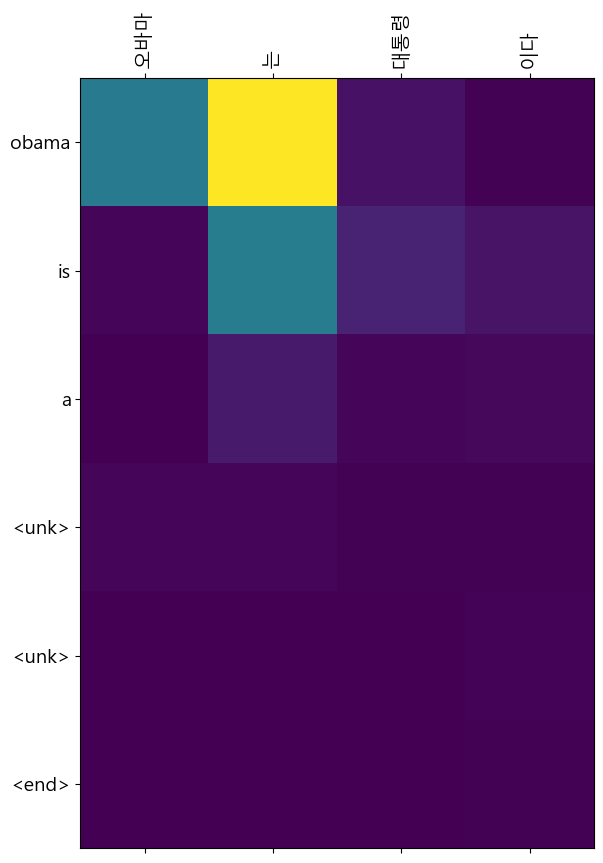

In [15]:
sentence = "오바마는 대통령이다."
result, preprocessed_sentence, attention_plot = evaluate(sentence)
print('Input:', sentence)
print('Translation:', result)
visualize_attention(attention_plot[:len(result.split()), :len(preprocessed_sentence)], preprocessed_sentence, result.split())

### 성능 향상을 위해 시도해볼 것

1. **“어휘 :”, “선서”, “oath”와 같이 단어 뜻풀이를 필터링하는 코드를 추가한다.**<br>
    → 모델은 "A는 B다"라는 문법을 배워야 하는데, "단어: 뜻" 같은 데이터가 섞여 있으면 어텐션이 혼란을 느낀다.<br>
    노이즈 제거는 성능 향상에 가장 큰 기여를 한다.
    
2. **따옴표(""), 괄호(), 금액 표시($) 등의 특수문자를 제거하는 코드를 ‘한국어’만 하지 않고, ‘영어’에도 구현한다.**<br>
    → `apple`, `apple.`, `"apple"` 모델은 모두 다른 단어로 인식한다. 영어에도 특수문자 전처리를 적용하면 단어 사전의 효율이 훨씬 좋아진다고 함.
    
3. **단어장 10000개 이상으로 설정한다.**<br>
    → 사전을 키우면 <unk>는 줄어들지만, 학습해야 할 파라미터가 늘어나 학습 속도가 느려짐.<br>
    데이터가 적을 경우 오히려 과적합이 심해질 수 있음 주의.
    
4. **epoch = 10이었던 걸, 줄이거나 늘려본다.**<br>
    → 에포크 7에서 정답이 나왔다면 10까지 갈 필요 없이 7~8 근처에서 멈추는 것이 가장 좋을 수도 있다. 이게 early stopping.